In [5]:
# Presentation:
# - Multi-Object

In [6]:
# reloads modules before executing
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from classes.observation import TransitionModel, ObservationModel
from classes.simulator import generate_random_balls, create_ground_truth_n_balls
from classes.plotting import plot_sim_n_balls_point_prediction, plot_particle_filter_step
from classes.evaluator import get_stats
from classes.tester import ParticleFilterTester
import numpy as np

[[  6.33712854  30.31653852 -22.43153567  22.50508133]
 [ 21.19351692  33.63950404  11.70587169  33.19429655]
 [ 13.48989461  26.78295595 -18.72796477  19.74081245]
 [ 30.75590681  31.36481323   0.75696809  32.17211198]
 [ 13.36935737  20.77725524 -15.22238106  19.361966  ]
 [ 40.05290231  23.00674652   2.77629997  22.78498067]
 [ 16.05372649  20.82729437  16.82922254  30.5175369 ]
 [ 25.89302538   9.74614768   1.67549819  25.23234963]
 [ 32.50340132  21.38039959 -19.36498641  35.37138172]
 [  8.6103669   42.21929791  24.82090279   6.32583707]
 [ 33.09199321  10.27966652   9.15039592  11.61811543]
 [ 37.3971622   28.95899892  18.8886289   29.11288831]
 [ 19.1812772   42.14412275 -17.07516938  17.98920835]
 [  8.6019532   44.32343431 -20.78893875  31.18783811]
 [ 21.44225     15.76771637  -5.99032909   4.88146456]
 [ 35.98041665  12.94127539 -15.2311604   24.19649007]
 [ 20.65557749  18.55689247 -11.30853716   4.24950223]
 [ 40.09131076  19.16784275  20.47102105   5.80274674]
 [  5.0741

,label,model,distance_metric,est_mean_error,est_rmse,obs_mean_error,obs_rmse,mse_improvement,rmse_improvement,raw,average_time
0,model=MultiParticleFilter_distance_metric=Eucl...,MultiParticleFilter,Euclidean,2.944766,3.680047,3.99329,4.512197,33.483317,18.442239,{'true_trajectory': [[[ 6.33712854 30.316538...,0.316526
1,model=MultiParticleFilter_distance_metric=Maha...,MultiParticleFilter,MahalanobisFilter,2.816338,3.374080,3.99329,4.512197,44.084195,25.223128,{'true_trajectory': [[[ 6.33712854 30.316538...,0.310526
2,model=MultiParticleFilter_distance_metric=LogL...,MultiParticleFilter,LogLikelihood,3.093146,3.940923,3.99329,4.512197,23.718390,12.660656,{'true_trajectory': [[[ 6.33712854 30.316538...,0.309993


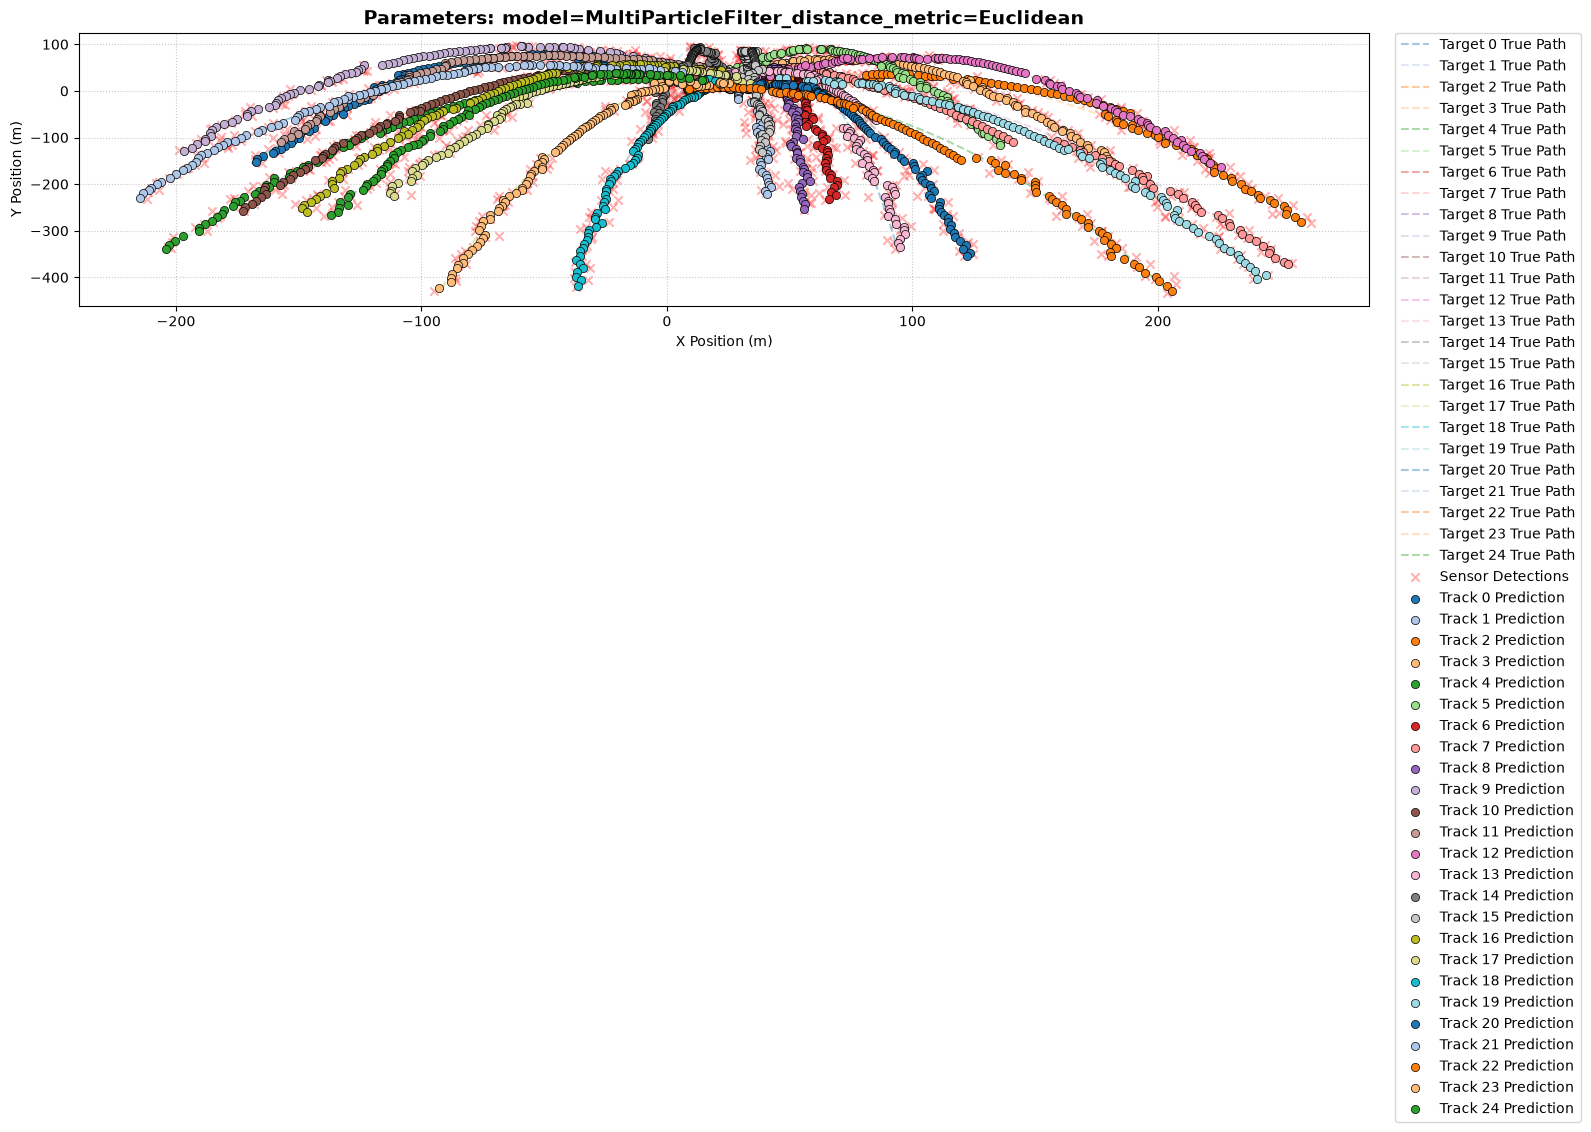

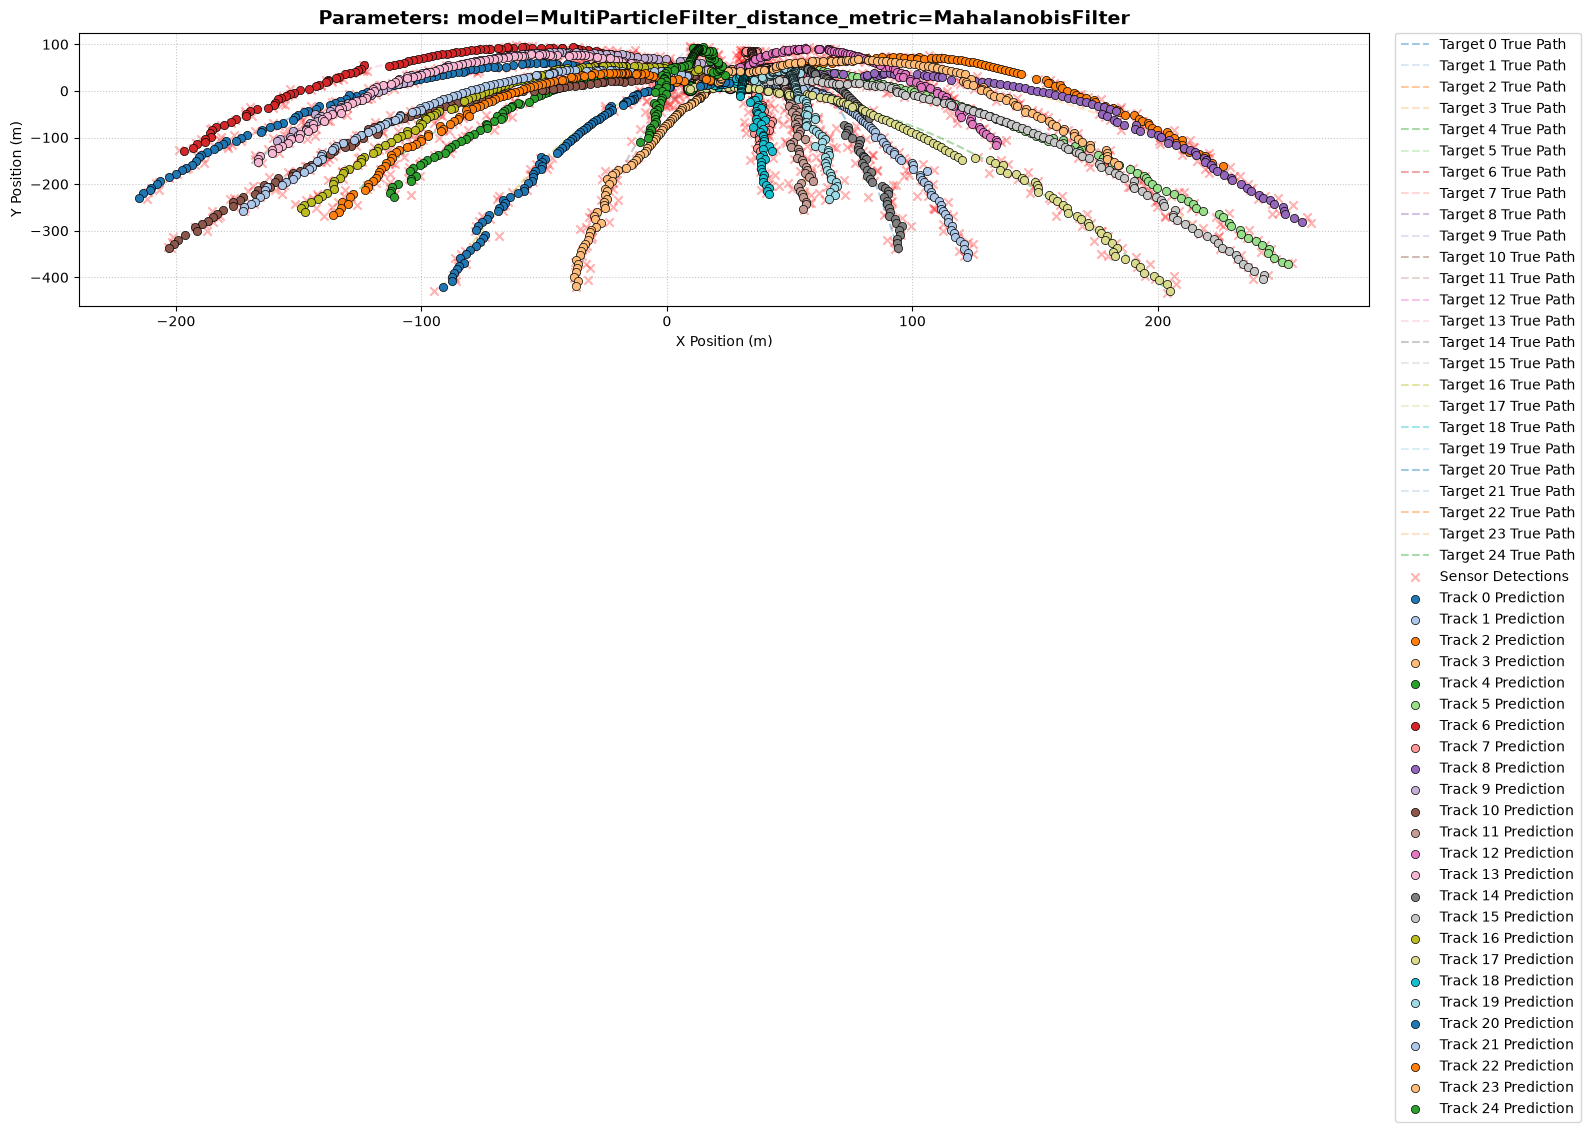

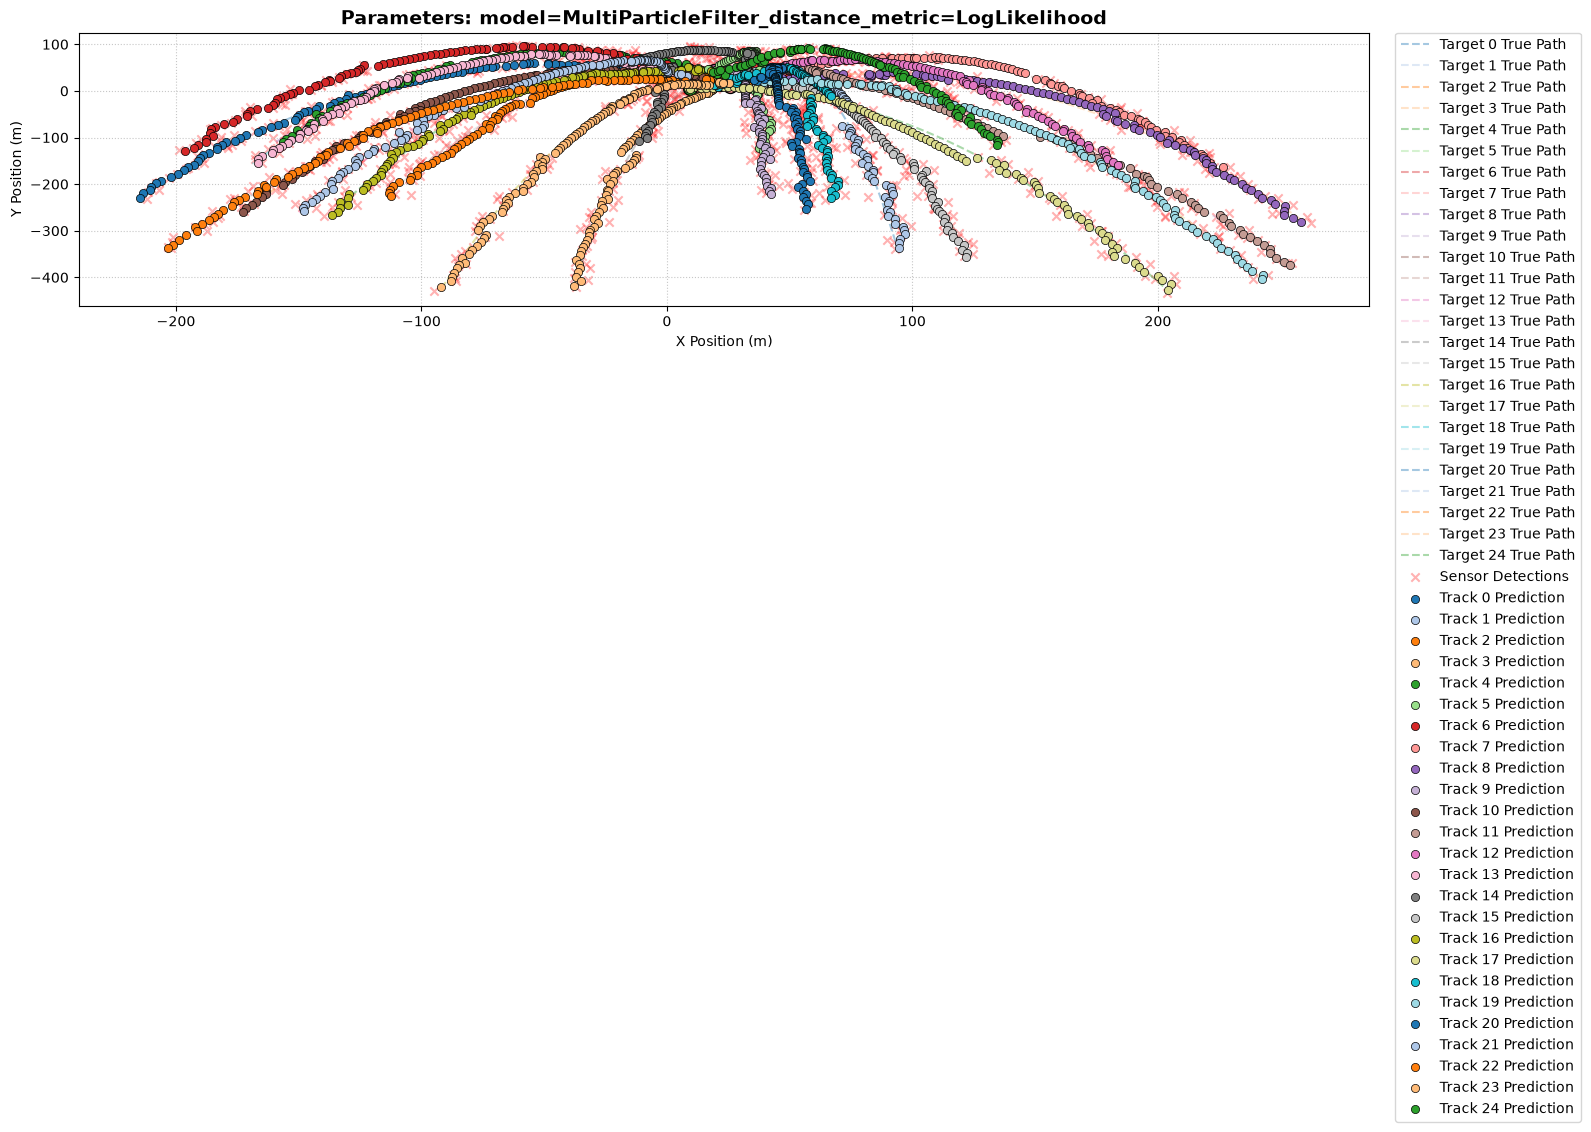

In [ ]:
seed = 5

STATE_BOUNDS = [
    (0.0, 50.0),    # x bounds
    (0.0, 50.0),    # y bounds
    (-30.0, 30.0),  # vx bounds
    (0.0, 40.0)     # vy bounds
]

# Simulation Parameters
dropout_start = 40
dropout_end = 60
process_noise = 0.01
measurement_noise = 25.0

# A LOT of balls:
true_states = generate_random_balls(num_balls=25, state_bounds=STATE_BOUNDS)
#true_states = np.array([[50.0, 50.0, 15.0, 25.0], [10.0, 10.0, 12.0, 30.0], [20.0, 20.0, 30.0, 3.0]], dtype=float)

n_objects = len(true_states)

# Build the ground truth + observations ONCE, before the filter runs --
# both assignment methods get tested against the exact same observation
# sequence, so any difference in results is purely due to the assignment
# strategy, not different noise draws.


input_parameters = {
    # Parameters for the simulation
    "step_size": 0.1,
    "num_steps": 100,

    # Parameters for the balls
    "true_states": true_states,
    "dropout_start": 40,
    "dropout_end": 60,
    "process_noise": 5, # Since we copy particles when resampling, process noise spreads them out in an area to make particles more diverse.
    "measurement_noise": 10,

    # Parameters for the Filter
    "model": "MultiParticleFilter", # Either "MultiParticleFilter" or "SingleParticleFilter"
    
    # Only Affects MultiParticleFilter
    "neighbor_assignment": "Hungarian", # Either "Hungarian" or "Greedy"
    "distance_metric": "Euclidean", # Either "MahalanobisObs" "MahalanobisFilter", "Euclidean", or "LogLikelihood"


    "num_particles": 1024, # For Multi-Object Particle Filter, this is the number of particles PER BALL
    "state_bounds": STATE_BOUNDS, 
    "init_generator": "Sobol", # Either "Sobol", "LHS", or "PseudoRandom"

    # Tested whether or not an estimate of velocity can be helpful
    # Assumption: The velocity estimates are too noisy to be useful, 
    #             and the filter is better off just relying on the position measurements
    "use_velocity_likelihood": False,
    "velocity_sigma": 10.0,
    "min_velocity_likelihood": 0.01,

    'ess_resample_threshold': 0.5 
}

tester = ParticleFilterTester(input_parameters, save_dir="results")

print(true_states)
results = tester.sweep_multi({
    "model": ["MultiParticleFilter"],
    "distance_metric": ["Euclidean", "MahalanobisFilter", "LogLikelihood"],
}, mode="grid", seed=seed)
results

<unknown>:47: SyntaxWarning: invalid escape sequence '\s'
<unknown>:65: SyntaxWarning: invalid escape sequence '\d'
<unknown>:280: SyntaxWarning: invalid escape sequence '\e'
<unknown>:291: SyntaxWarning: invalid escape sequence '\s'
<unknown>:47: SyntaxWarning: invalid escape sequence '\s'
<unknown>:65: SyntaxWarning: invalid escape sequence '\d'
<unknown>:280: SyntaxWarning: invalid escape sequence '\e'
<unknown>:291: SyntaxWarning: invalid escape sequence '\s'


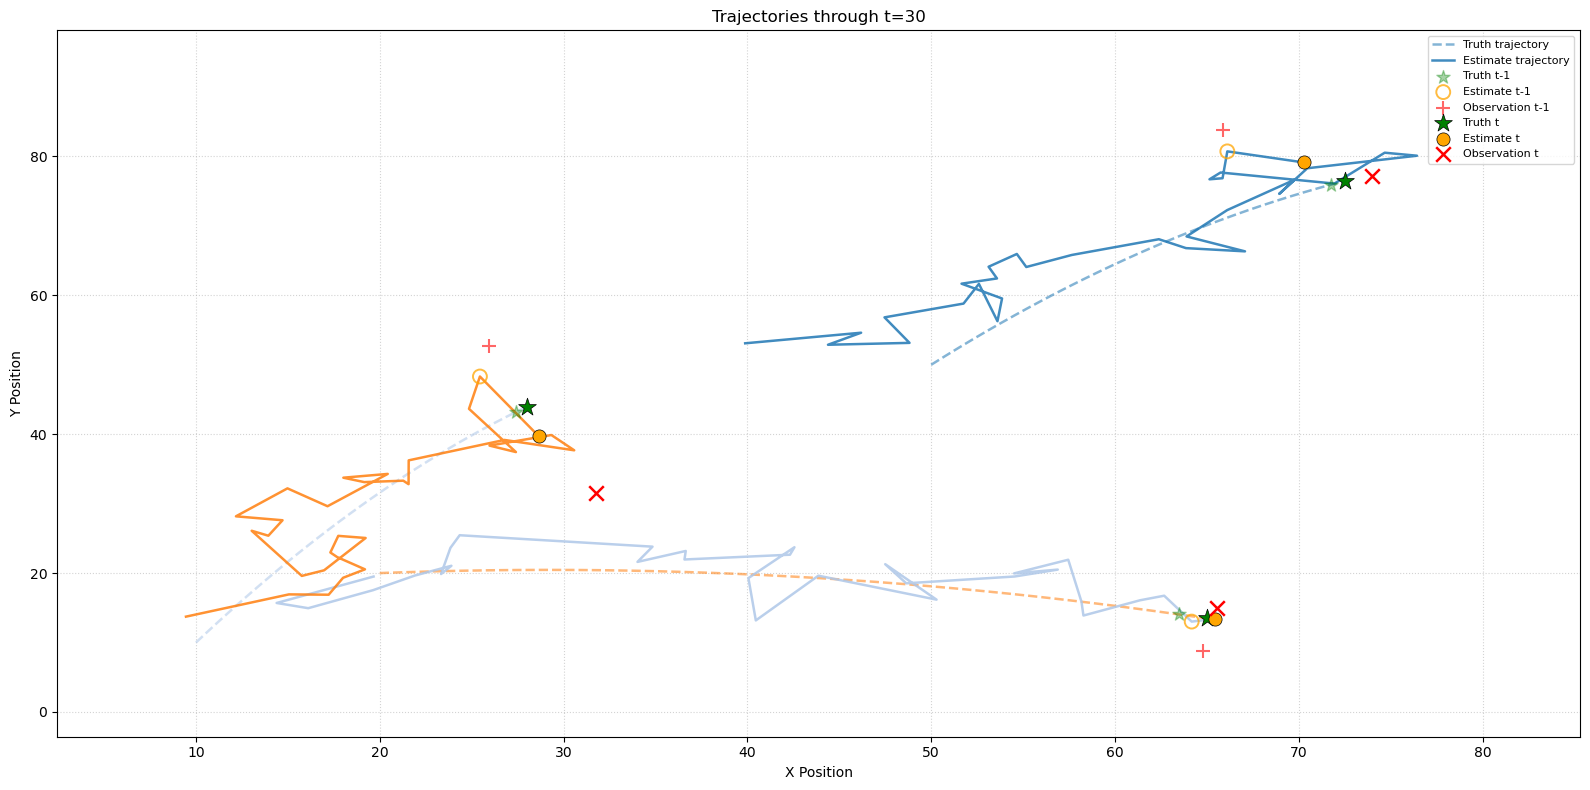

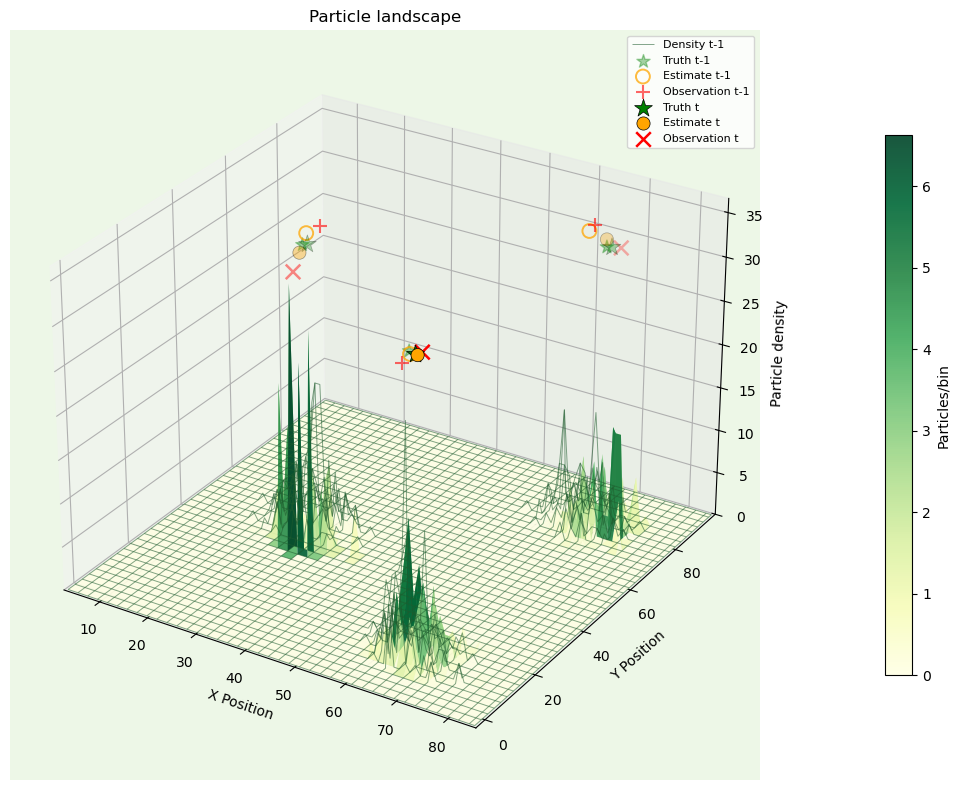

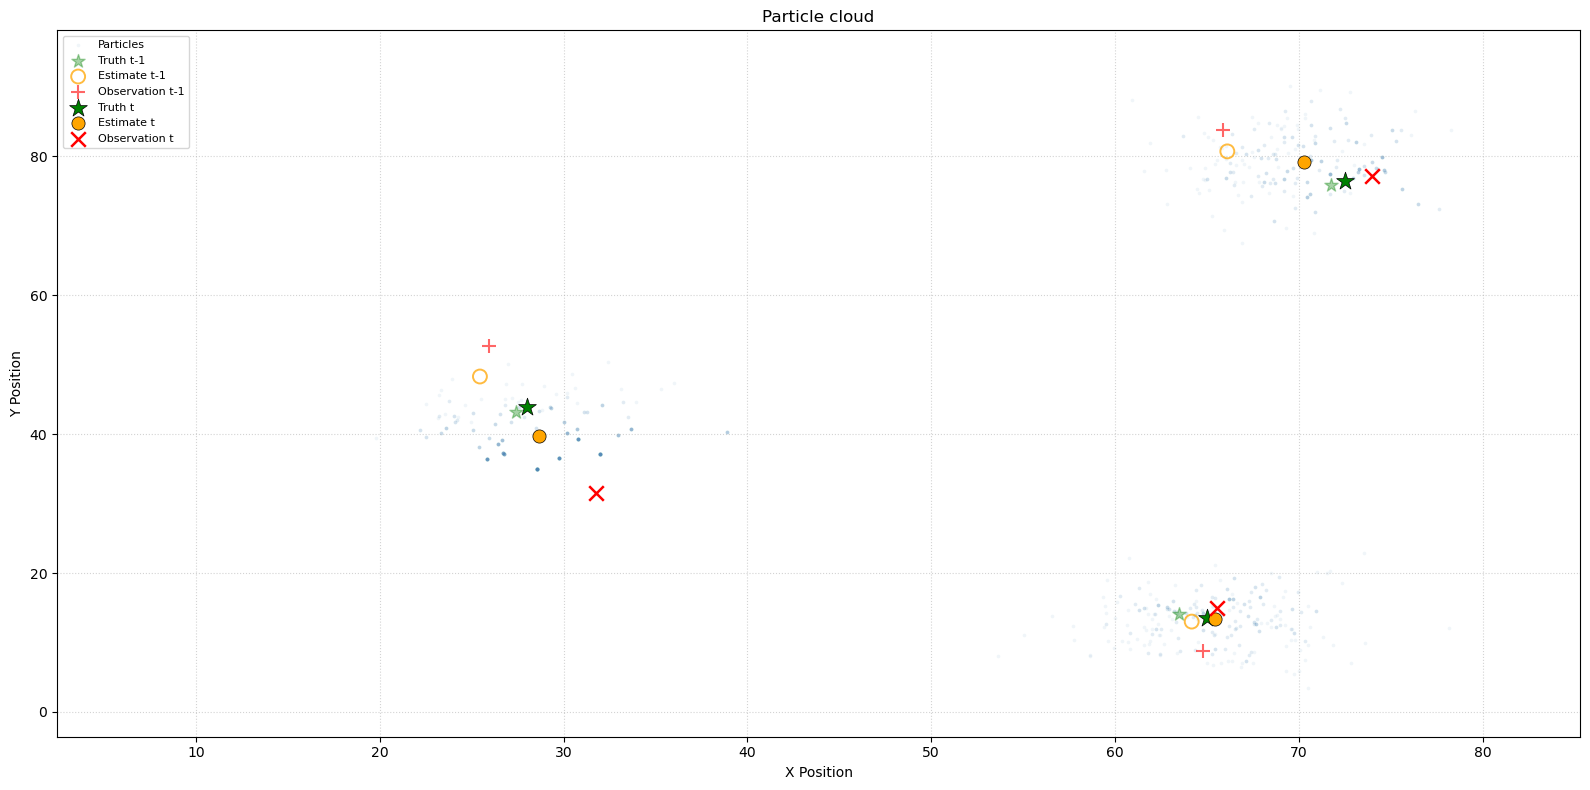

((<Figure size 1600x800 with 1 Axes>,
  <Figure size 1600x800 with 2 Axes>,
  <Figure size 1600x800 with 1 Axes>),
 (<Axes: title={'center': 'Trajectories through t=30'}, xlabel='X Position', ylabel='Y Position'>,
  <Axes3D: title={'center': 'Particle landscape'}, xlabel='X Position', ylabel='Y Position', zlabel='Particle density'>,
  <Axes: title={'center': 'Particle cloud'}, xlabel='X Position', ylabel='Y Position'>))

In [25]:
plot_particle_filter_step(time=30, **results["raw"])

In [5]:
n_objects = 5
step_size = 0.05
num_steps = 120
dropout_start = -1
dropout_end = -1
process_noise = 1

measurement_noise = 1000

STATE_BOUNDS = [
    (0.0, 50.0),    # x bounds
    (0.0, 50.0),    # y bounds
    (-30.0, 30.0),  # vx bounds
    (0.0, 40.0)     # vy bounds
]


num_particles = 1000
init_generator = "Sobol"


# Crossing Each Other
# true_states_multi = np.array([
#     [20.0, 20.0, 2.0, 25.0],
#     [20.0, 20.0, 2.0, 30.0],
#     [30.0, 20.0, -2.0, 25.0],
#     [30.0, 20.0, -2.0, 30.0]
# ], dtype=float)

# Similar Trajectories
# true_states_multi = np.array([
#     [5.0, 5.0, 18.0, 25.0],
#     [5.0, 5.0, 18.0, 30.0],
#     [5.0, 5.0, 18.0, 35.0],
#     [5.0, 5.0, 18.0, 40.0]
# ], dtype=float)

# Create multi-ball physics models
true_states_multi = generate_random_balls(n_objects, STATE_BOUNDS)

transition_model = TransitionModel(delta_t=step_size, process_noise=1)

observation_model = ObservationModel("Gaussian", measurement_noise=measurement_noise)
model_transition_model = TransitionModel(delta_t=step_size, process_noise=process_noise)

# Generate multi-ball paths and sensor reads
true_trajectory_multi, observations_multi = create_ground_truth_n_balls(
    num_steps, dropout_start, dropout_end, true_states_multi, transition_model, observation_model
)

# Initialize Particle Filter with expanded particle cloud for multi-modality
pf_multi = MultiObjectParticleFilter(
    num_particles=num_particles,
    n_balls=n_objects,
    state_bounds=STATE_BOUNDS,
    transition_model=model_transition_model,
    observation_model=observation_model,
    init_generator=init_generator,
)

# pf_single = ParticleFilter(
#     num_particles=num_particles * n_objects,  # more particles to equalize playing field
#     state_bounds=state_bounds,
#     transition_model=model_transition_model,
#     observation_model=observation_model,
#     init_generator=init_generator,
#     roughening_noise=roughening_noise
# )

# Run the tracking engine
history_multi = pf_multi.run(observations_multi)

# history_single = pf_single.run(observations_multi, n_objects=n_objects)


c:\THWS\THWS\1. Semester\RDM\New_Particle_Filter\classes\particle_filter_multiple.py:117: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  samples = sampler.random(n=self.num_particles)


In [6]:
# plot_sim_n_balls_point_prediction(
#     true_trajectory_multi,
#     observations_multi,
#     history_single,
#     dropout_start,
#     dropout_end
# )

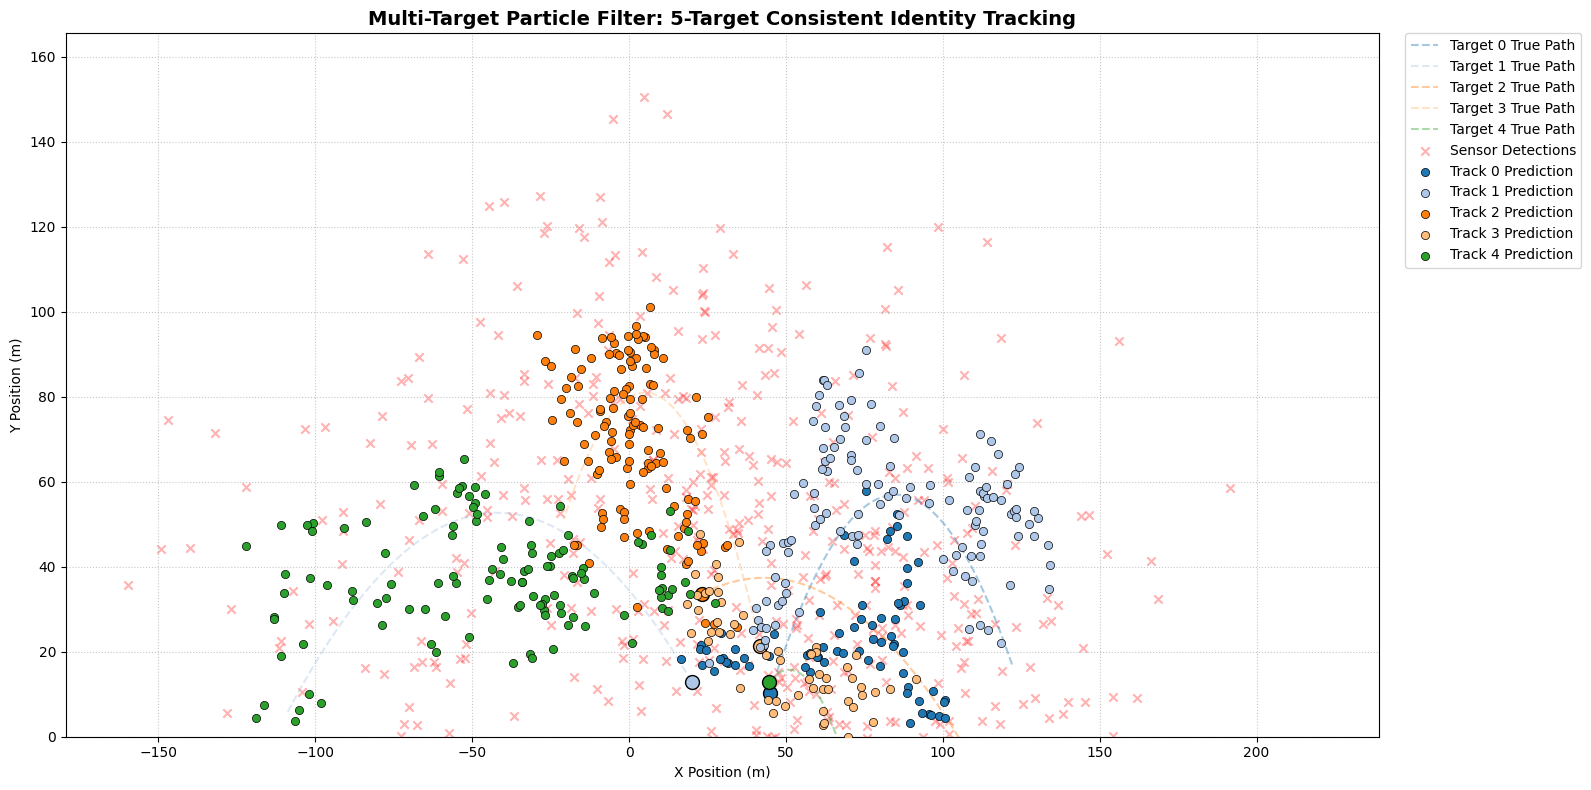

In [7]:
plot_sim_n_balls_point_prediction(
    true_trajectory_multi,
    observations_multi,
    history_multi,
    dropout_start,
    dropout_end
)

In [8]:
# animate_particle_filter(true_trajectory_multi, history_multi, save_path="particle_filter_multiple_animation.gif")
# animate_particle_filter(true_trajectory_multi, history_single, save_path="particle_filter_single_animation.gif")


In [11]:

get_stats(true_trajectory_multi, observations_multi, history_multi, num_steps)
# print_stats(true_trajectory_multi, observations_multi, history_single, num_steps)

{'est_mean_error': np.float64(11.64741717730422),
 'est_rmse': np.float64(12.641981556195505),
 'obs_mean_error': np.float64(12.608677280256002),
 'obs_rmse': np.float64(13.621616857203048)}